In [2]:
import os
import torch
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta
import tropycal.tracks as tracks
import matplotlib.patches as mpatches
import glob
import warnings
import aurora
from aurora import Tracker
from aurora import Batch, Metadata

/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/tropycal/_version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
/glade/work/turuncu/ML/envs/aurora/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Analyses for Hurricane Irene

Hurricane Irene was a large and powerful Atlantic hurricane that left extensive flood and wind damage along its path through the Caribbean, the United States East Coast and as far north as Canada. Irene made landfall near Cape Lookout, North Carolina at around 7:30 AM EDT on August 27, 2011 as a strong category 1 storm.

**More information:**

https://www.nhc.noaa.gov/data/tcr/AL092011_Irene.pdf

https://www.weather.gov/mhx/aug272011eventreview

https://www.weather.gov/gyx/Irene_Anniversary

### Arguments

In [4]:
# Arguments
start_date = "2011-08-21T00:00:00"
start_date = datetime.strptime(start_date, "%Y-%m-%dT%H:%M:%S")
end_date = "2011-08-30T00:00:00"
end_date=datetime.strptime(end_date, "%Y-%m-%dT%H:%M:%S")
time_delta = 6
time_range = pd.date_range(start_date, end_date, freq=f"{time_delta}h").strftime('%Y-%m-%dT%H:%M:%S').to_list()

# Path for Aurora predictions
data_path = "/glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene/"

### Get track from HURDAT2 dataset

In [5]:
# Get best track data
basin = tracks.TrackDataset(basin='north_atlantic', source='hurdat', include_btk=True)
storm = basin.get_storm(("irene", 2011))
storm

--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (2.18 seconds)
--> Starting to read in best track data
--> Completed reading in best track data (3.65 seconds)


<tropycal.tracks.Storm>
Storm Summary:
    Maximum Wind:      105 knots
    Minimum Pressure:  942 hPa
    Start Time:        0000 UTC 21 August 2011
    End Time:          1800 UTC 28 August 2011

Variables:
    time        (datetime) [2011-08-21 00:00:00 .... 2011-08-30 00:00:00]
    extra_obs   (int64) [0 .... 0]
    special     (str) [ .... ]
    type        (str) [TS .... EX]
    lat         (float64) [15.0 .... 53.0]
    lon         (float64) [-59.0 .... -60.0]
    vmax        (int64) [45 .... 40]
    mslp        (int64) [1006 .... 991]
    wmo_basin   (str) [north_atlantic .... north_atlantic]

More Information:
    id:              AL092011
    operational_id:  AL092011
    name:            IRENE
    year:            2011
    season:          2011
    basin:           north_atlantic
    source_info:     NHC Hurricane Database
    source:          hurdat
    ace:             18.8
    realtime:        False
    invest:          False
    subset:          False

### Run Aurora provided tracking tool over previously generated predictions

We are triggering tracking algorithm every 6-hour starting from 2011-08-21T00:00:00 to 2011-08-30T00:00:00. 
The number of steps used in the tracker is the actual distance to 2011-08-30T00:00:00 for each prediction. 
So, the number of steps is decreasing along with going forward in the prediction.

In [6]:
# Loop over files
init_lat=15.0
init_lon=-59.0
files = sorted(glob.glob(os.path.join(data_path, "pred_*.nc")))
for f in files:
    # Load dataset
    ds_aurora = xr.open_dataset(f)

    # Check output file
    ofile = f"track_{pd.to_datetime(ds_aurora.time.values[0]).strftime('%Y-%m-%dT%H:%M:%S')}.nc"
    if os.path.exists(ofile):
        print(f"File {ofile} already exists. Skipping...")
        continue

    # Debugging
    print(f"Load {f} - {ds_aurora.time.values[0]} - {init_lat}/{init_lon}")

    # Init tracker
    tracker = Tracker(init_lat=init_lat, init_lon=init_lon, init_time=ds_aurora.time.values[0])

    # Loop over time steps
    for t in ds_aurora.time.values:
        # Create batch
        data = ds_aurora.sel(time=t)
        batch = Batch(
            surf_vars={
                "2t": torch.from_numpy(data["2t"].values[None]),
                "10u": torch.from_numpy(data["10u"].values[None]),
                "10v": torch.from_numpy(data["10v"].values[None]),
                "msl": torch.from_numpy(data["msl"].values[None]),
            },
            static_vars={
                # The static variables are constant, so we just get them for the first time. They
                # don't need to be flipped along the latitude dimension, because they are from
                # ERA5.
                "z": torch.from_numpy(data["z"].values),
                "slt": torch.from_numpy(data["slt"].values),
                "lsm": torch.from_numpy(data["lsm"].values),
            },
            atmos_vars={
                "t": torch.from_numpy(data["t"].values[None]),
                "u": torch.from_numpy(data["u"].values[None]),
                "v": torch.from_numpy(data["v"].values[None]),
                "q": torch.from_numpy(data["q"].values[None]),
                "z": torch.from_numpy(data["z"].values[None]),
            },
            metadata=Metadata(
                # Flip the latitudes! We need to copy because converting to PyTorch, because the
                # data must be contiguous.
                lat=torch.from_numpy(data.latitude.values),
                lon=torch.from_numpy(data.longitude.values),
                # Converting to `datetime64[s]` ensures that the output of `tolist()` gives
                # `datetime.datetime`s. Note that this needs to be a tuple of length one:
                # one value for every batch element. Select the third time point.
                #time=(data.time.values.astype("datetime64[s]").tolist()[2],),
                time=(data.time.values,),
                atmos_levels=tuple(int(level) for level in data.level.values),
            ),
        )

        # Run tracker
        tracker.step(batch)

    # Store results
    if os.path.exists(ofile):
        os.remove(ofile)
    ds = xr.Dataset.from_dataframe(tracker.results())
    ds.to_netcdf(ofile)

    # Update init_lat and init_lon
    init_lat = ds.lat.values[1]
    init_lon = ds.lon.values[1]

File track_2011-08-21T00:00:00.nc already exists. Skipping...
File track_2011-08-21T06:00:00.nc already exists. Skipping...
File track_2011-08-21T12:00:00.nc already exists. Skipping...
File track_2011-08-21T18:00:00.nc already exists. Skipping...
File track_2011-08-22T00:00:00.nc already exists. Skipping...
File track_2011-08-22T06:00:00.nc already exists. Skipping...
File track_2011-08-22T12:00:00.nc already exists. Skipping...
File track_2011-08-22T18:00:00.nc already exists. Skipping...
File track_2011-08-23T00:00:00.nc already exists. Skipping...
File track_2011-08-23T06:00:00.nc already exists. Skipping...
File track_2011-08-23T12:00:00.nc already exists. Skipping...
File track_2011-08-23T18:00:00.nc already exists. Skipping...
File track_2011-08-24T00:00:00.nc already exists. Skipping...
File track_2011-08-24T06:00:00.nc already exists. Skipping...
File track_2011-08-24T12:00:00.nc already exists. Skipping...
File track_2011-08-24T18:00:00.nc already exists. Skipping...
File tra

### Run Aurora provided tracking tool using ERA5

In [6]:
# Create dataset
era5_path = '/glade/derecho/scratch/turuncu/data/Data_aurora/split_files'
files = sorted(glob.glob(os.path.join(era5_path, "data_*.nc")))
ds_era5 = xr.open_mfdataset(files, data_vars="all", chunks='auto', engine="netcdf4").sel(time=time_range)
ds_era5 = ds_era5.expand_dims('batch')

In [8]:
# Init tracker
init_lat=15.0
init_lon=-59.0
tracker = Tracker(init_lat=init_lat, init_lon=360+init_lon, init_time=ds_era5.time.values[0])

# Loop over timesteps
for t in time_range:
    print(t)
    # Create batch
    data = ds_era5.sel(time=t)
    batch = Batch(
        surf_vars={
            "2t": torch.from_numpy(data["t2m"].values[None]),
            "10u": torch.from_numpy(data["u10"].values[None]),
            "10v": torch.from_numpy(data["v10"].values[None]),
            "msl": torch.from_numpy(data["msl"].values[None]),
        },
        static_vars={
            "z": torch.from_numpy(data["hgt"].values),
            "slt": torch.from_numpy(data["slt"].values),
            "lsm": torch.from_numpy(data["lsm"].values),
        },
        atmos_vars={
            "t": torch.from_numpy(data["t"].values[None]),
            "u": torch.from_numpy(data["u"].values[None]),
            "v": torch.from_numpy(data["v"].values[None]),
            "q": torch.from_numpy(data["q"].values[None]),
            "z": torch.from_numpy(data["z"].values[None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(data.latitude.values),
            lon=torch.from_numpy(data.longitude.values),
            time=(data.time.values,),
            atmos_levels=tuple(int(level) for level in data.level.values),
        ),
    )

    # Run tracker
    tracker.step(batch)

# Store results
ofile = "track_era5.nc"
if os.path.exists(ofile):
    os.remove(ofile)
ds = xr.Dataset.from_dataframe(tracker.results())
ds.to_netcdf(ofile)

2011-08-21T00:00:00
2011-08-21T06:00:00
2011-08-21T12:00:00
2011-08-21T18:00:00
2011-08-22T00:00:00
2011-08-22T06:00:00
2011-08-22T12:00:00
2011-08-22T18:00:00
2011-08-23T00:00:00
2011-08-23T06:00:00
2011-08-23T12:00:00
2011-08-23T18:00:00
2011-08-24T00:00:00
2011-08-24T06:00:00
2011-08-24T12:00:00
2011-08-24T18:00:00
2011-08-25T00:00:00
2011-08-25T06:00:00
2011-08-25T12:00:00
2011-08-25T18:00:00
2011-08-26T00:00:00
2011-08-26T06:00:00
2011-08-26T12:00:00
2011-08-26T18:00:00
2011-08-27T00:00:00
2011-08-27T06:00:00
2011-08-27T12:00:00
2011-08-27T18:00:00
2011-08-28T00:00:00
2011-08-28T06:00:00
2011-08-28T12:00:00
2011-08-28T18:00:00
2011-08-29T00:00:00
2011-08-29T06:00:00
2011-08-29T12:00:00
2011-08-29T18:00:00
2011-08-30T00:00:00


### Create Tracking Plot

(27686.20581280247, 26714.7599948094, 32057.711993771278, 33514.88072076088, 34486.32653875395, 34486.32653875395, 35457.77235674702, 36429.21817474009, 37400.663992733156, 38372.10981072622, 38372.10981072622, 38857.83271972276, 38857.83271972276, 39829.27853771582, 40800.7243557089, 42257.8930826985, 43715.06180968811, 45657.95344567425, 47600.84508166039, 50029.45962664305, 52458.074171625725, 55372.41162560494, 57801.026170587604, 60229.64071557028, 62172.532351556416, 63143.97816954949, 64115.423987542556, 65086.869805535614, 65572.59271453216, 66544.03853252523, 67515.4843505183, 68001.20725951482, 68001.20725951482, 68486.93016851136, 69944.09889550097, 72372.71344048364, 75287.05089446285, nan) (585143.7582303459, 584655.9915217075, 578803.0561543938, 575876.7710431679, 573438.2924876714, 570999.8975221191, 569049.2414930242, 567098.6385476729, 565635.7210642508, 563197.5911727105, 561247.1463754154, 558809.163972162, 557346.413642171, 556371.2630043069, 555396.1253386851, 5539

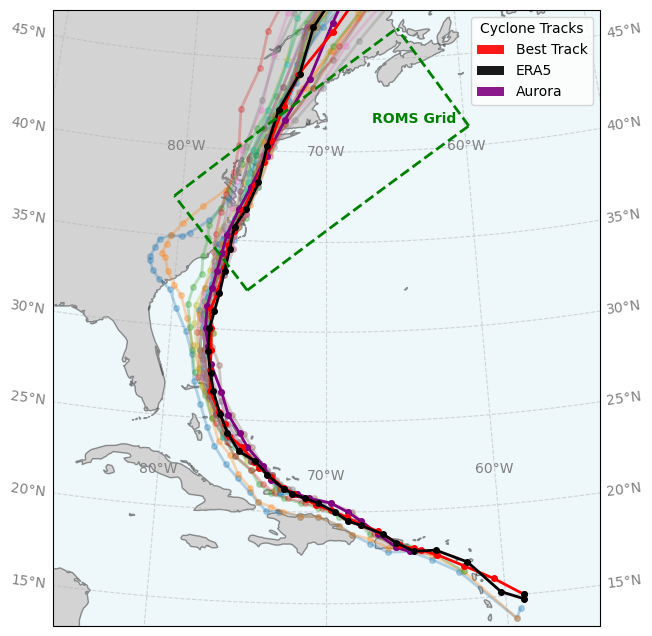

In [25]:
# Define bounding box limits
min_lat, max_lat = 13, 47
min_lon, max_lon = 275, 305

# Create figure with cartopy projection
plt.figure(figsize=(10, 8))
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0,
    central_latitude=(min_lat+max_lat)/2.0,
    standard_parallels=(20.0, 40.0)
)
ax = plt.axes(projection=projection)

# Add map features
ax.add_feature(cfeature.COASTLINE, alpha=0.4)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)
ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Axes
gl = ax.gridlines(crs=ccrs.PlateCarree(), alpha=0.5, linestyle='--', draw_labels=True)
gl.xlines = True
gl.ylines = True
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot Aurora
files = sorted(glob.glob("track_*.nc"))
alpha = 0.3
colors = plt.get_cmap('viridis')(np.linspace(0, 1, len(files)-1))
id = 0
ds_list = []
for f in files[1:]:
    ds = xr.open_dataset(f)
    ds_list.append(ds)
    color = id
    ax.plot(
        ds.lon,
        ds.lat,
        #color=colors[id],
        alpha=alpha,
        marker="o",
        markersize=4,
        linewidth=2,
        label="Aurora",
        transform=ccrs.PlateCarree(),
    )
    id = id+1

# Calculate mean track from predications
target_epsg='3857'
crs_4326 = pyproj.CRS("EPSG:4326") # WGS84
crs_target = pyproj.CRS(f"EPSG:{target_epsg}")
transformer = pyproj.Transformer.from_crs(crs_4326, crs_target, always_xy=True)

t_list = pd.date_range(start_date, end_date, freq=f"{time_delta}h").to_list()
ds_tracks_merged = xr.concat(ds_list, dim='track_id')
x = []
y = []
for id in ds_tracks_merged.track_id:
    mask_time = [ True if t in t_list else False for t in ds_tracks_merged.sel(track_id=id).time]
    lon_local = [ds_tracks_merged.sel(track_id=id, index=i).lat.values.item() if mt else np.nan for i, mt in enumerate(mask_time)]
    lat_local = [ds_tracks_merged.sel(track_id=id, index=i).lon.values.item() if mt else np.nan for i, mt in enumerate(mask_time)]
    res = [transformer.transform(lon*math.pi/180, lat*math.pi/180) for lat, lon in zip(lat_local, lon_local)]
    x_local, y_local = zip(*res)
    x.append(list(x_local))
    y.
    print(x, y)
    break
    #lat.append(np.array([ds_tracks_merged.sel(track_id=id, index=i).lat.values.item() if mt else np.nan for i, mt in enumerate(mask_time)]))
    #lon.append(np.array([ds_tracks_merged.sel(track_id=id, index=i).lon.values.item() if mt else np.nan for i, mt in enumerate(mask_time)]))
#lon = np.array(lon)
#lat = np.array(lat)
#import pygeodesy as pg


#lon_mean = np.zeros(ds_tracks_merged.sel(track_id=0).time.shape[0])
#lat_mean = np.zeros(ds_tracks_merged.sel(track_id=0).time.shape[0])
#count = np.zeros(ds_tracks_merged.sel(track_id=0).time.shape[0])
#for id in ds_tracks_merged.track_id:
#    mask_time = [ True if t in tr else False for t in ds_tracks_merged.sel(track_id=id).time]
#    lon_local = np.array([ds_tracks_merged.sel(track_id=id, index=i).lon.values.item() if mt else np.nan for i, mt in enumerate(mask_time)])
#    lat_local = np.array([ds_tracks_merged.sel(track_id=id, index=i).lat.values.item() if mt else np.nan for i, mt in enumerate(mask_time)])
#    count_local = np.array([1 if mt else 0 for mt in mask_time])
#    for lon, lat in zip(lon_local, lat_local):
#        df = pd.DataFrame({'lat': lat, })
#    #df = pd.DataFrame({'lat': lat_local, })
#    #stacked_lon = np.array([lon, lon_local])
#    #stacked_lat = np.array([lat, lat_local])
#    #lon = np.nansum(stacked_lon, axis=0)
#    #lat = np.nansum(stacked_lat, axis=0)
#    #cnt = cnt+cnt_local
#lon = lon/cnt
#lat = lat/cnt

# Plot Auora starting from 2011-08-21T06:00:00
#ds_model = xr.open_dataset(files[5])
#ax.plot(
#    lon,
#    ds_model.lat,
#    color="gold",
#    marker="o",
#    markersize=4,
#    linewidth=2,
#    label="Aurora",
#    transform=ccrs.PlateCarree(),
#)

# Plot Auora starting from 2011-08-21T06:00:00
ds_model = xr.open_dataset(files[5])
ax.plot(
    ds_model.lon,
    ds_model.lat,
    color="purple",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Aurora",
    transform=ccrs.PlateCarree(),
)

# Plot best track
ax.plot(
    storm.lon,
    storm.lat,
    color="red",
    marker="o",
    markersize=4,
    linewidth=2,
    label="HURDAT2",
    transform=ccrs.PlateCarree(),
)

# Plot ERA5
ds_era5 = xr.open_dataset("track_era5.nc")
ax.plot(
    ds.lon,
    ds.lat,
    color="black",
    marker="o",
    markersize=4,
    linewidth=2,
    label="ERA5",
    transform=ccrs.PlateCarree(),
)

# Add legend
best_patch = mpatches.Rectangle((0, 0), 1, 1, fc="red", alpha=0.9, label="Best Track")
era5_patch = mpatches.Rectangle((0, 0), 1, 1, fc="black", alpha=0.9, label="ERA5")
model_patch = mpatches.Rectangle((0, 0), 1, 1, fc="purple", alpha=0.9, label="Aurora")
ax.legend(handles=[best_patch, era5_patch, model_patch], loc="upper right", title="Cyclone Tracks")

# Add ROMS grid box
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')
ax.plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
ax.plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Top
ax.plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Left
ax.plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='green', linewidth=2, linestyle='--', transform=ccrs.PlateCarree()) # Right
ax.text(grid.lon_rho[0, -1]-7, grid.lat_rho[0, -1]+0.5, 'ROMS Grid', fontweight='bold', color='green', fontsize=10, transform=ccrs.PlateCarree())

# Save figure
plt.savefig(f"Fig_cyclone_tracks_irene.png", bbox_inches="tight", dpi=300)

In [7]:
# Define x axis
x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")

In [8]:
# Prepare HURDAT2
dict = {
    'time': [],
    'mslp': [],
    'vmax': []
}
for i in range(len(storm.lon)):
    if storm.time[i] in x:
        dict['time'].append(storm.time[i])
        dict['mslp'].append(storm.vars['mslp'][i])
        dict['vmax'].append(storm.vars['vmax'][i])

In [9]:
# Prepare Aurora Prediction
dstr = ['2011-08-21T06:00:00', '2011-08-24T06:00:00', '2011-08-27T06:00:00']
data_model = []
for d in dstr:
    ds_track = xr.open_dataset(f"track_{d}.nc")
    first = True
    for i in range(len(ds_track.index)):
        if ds_track.time.values[i] in x:
            if first:
                data_model.append(
                    {
                        'time': [],
                        'mslp': [],
                        'vmax': []
                    }
                )
            data_model[-1]['time'].append(ds_track.time.values[i])
            data_model[-1]['mslp'].append(ds_track['msl'].values[i]/100.0)
            data_model[-1]['vmax'].append(ds_track['wind'].values[i])
            first = False

<class 'numpy.datetime64'>
<class 'numpy.datetime64'>
<class 'numpy.datetime64'>


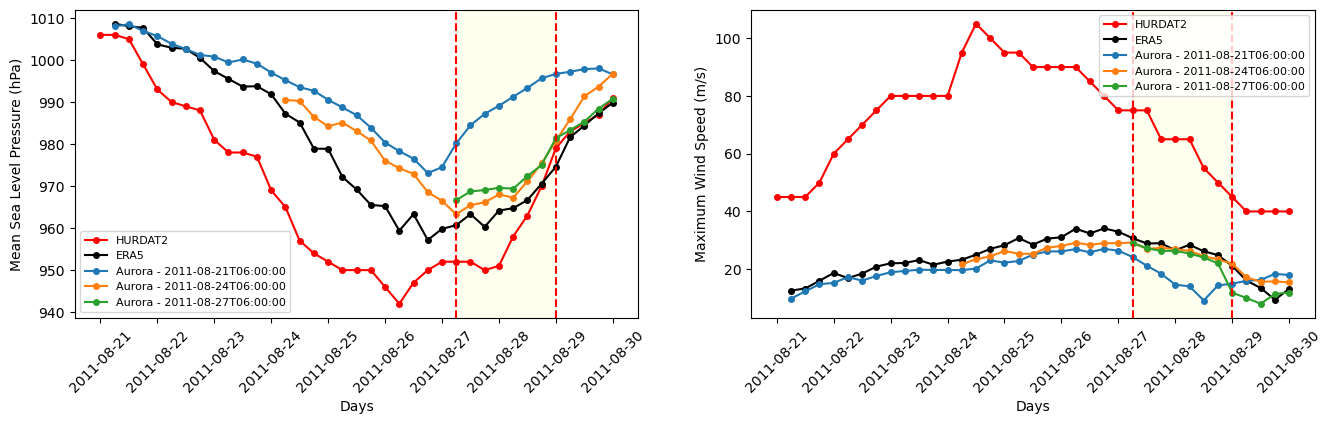

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(16,4))
x = pd.date_range(start_date, end_date, freq=f"{time_delta}h")

ax[0].plot(x, dict['mslp'], color="red", marker="o", markersize=4, label="HURDAT2")
ax[0].plot(x, ds_era5['msl'][:-1]/100.0, color="black", marker="o", markersize=4, label="ERA5")
for d in data_model:
    print(type(d['time'][0]))
    ax[0].plot(d['time'], d['mslp'], marker="o", markersize=4, label=f"Aurora - {pd.to_datetime(d['time'][0]).strftime('%Y-%m-%dT%H:%M:%S')}")
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].legend(ncol=1, fontsize=8, loc='lower left')
ax[0].set_xlabel('Days')
ax[0].set_ylabel('Mean Sea Level Pressure (hPa)')
ax[0].axvline(x=x[25], color='r', linestyle='--') # 2011-08-27 06:00:00
ax[0].axvline(x=x[32], color='r', linestyle='--') # 2011-08-29T00:00:00
ax[0].axvspan(x[25], x[32], color='lightyellow', alpha=0.5)

ax[1].plot(x, dict['vmax'], color="red", marker="o", markersize=4, label="HURDAT2")
ax[1].plot(x, ds_era5['wind'][:-1], color="black", marker="o", markersize=4, label="ERA5")
for d in data_model:
    ax[1].plot(d['time'], d['vmax'], marker="o", markersize=4, label=f"Aurora - {pd.to_datetime(d['time'][0]).strftime('%Y-%m-%dT%H:%M:%S')}")
ax[1].tick_params(axis='x', labelrotation=45)
ax[1].legend(ncol=1, fontsize=8, loc='upper right')
ax[1].set_xlabel('Days')
ax[1].set_ylabel('Maximum Wind Speed (m/s)')
ax[1].axvline(x=x[25], color='r', linestyle='--') # 2011-08-27 06:00:00
ax[1].axvline(x=x[32], color='r', linestyle='--') # 2011-08-29T00:00:00
ax[1].axvspan(x[25], x[32], color='lightyellow', alpha=0.5)

### Coupled Simulation Results

**Table 1:** Detailed information about conducted simulations
| #  | Data Component | Input     | Temporal Interpolation Type | Coupling Type      | Feedback                 |
|----|----------------|-----------|-----------------------------|--------------------|--------------------------|
| r1 | CDEPS          | ERA5 (6h) | coszen                      | one-way: ATM->OCN  | No                       |
| r2 | CDEPS          | ERA5 (1h) | coszen                      | one-way: ATM->OCN  | No                       |
| r3 | CDEPS          | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r4 | CDEPS          | ERA5 (1h) | linear                      | one-way: ATM->OCN  | No                       |
| r5 | Aurora         | ERA5 (6h) | linear                      | one-way: ATM->OCN  | No                       |
| r6 | Aurora         | ERA5 (6h) | linear                      | two-way: ATM<->OCN | Yes, SST from OCN to ATM |

In [156]:
# List of variables to keep
vars = {
    'Pair': [995, 1015],
    'Tair': [20, 28],
    'Uwind': [-5, 10],
    'Vwind': [0, 12],
    'swrad': [50, 200],
    'lwrad': [-25, 25],
    'latent': [-100, 100],
    'sensible': [-20, 100],
    'temp': [16, 26],
    'zeta' : [-0.2, 0.6]
}
var_names = list(vars.keys())

# Open datasets and merge them
# No shift means that the origianal ERA5 dataset not shifted in time
ds1 = xr.open_dataset("../run_cdeps/r1_no_shift/irene_his.nc").isel(s_rho=-1)[var_names]
ds2 = xr.open_dataset("../run_cdeps/r2_no_shift/irene_his.nc").isel(s_rho=-1)[var_names]
ds3 = xr.open_dataset("../run_cdeps/r3_no_shift/irene_his.nc").isel(s_rho=-1)[var_names]
ds4 = xr.open_dataset("../run_cdeps/r4_no_shift/irene_his.nc").isel(s_rho=-1)[var_names]
ds5 = xr.open_dataset("../run/r5/irene_his.nc").isel(s_rho=-1)[var_names]
ds6 = xr.open_dataset("../run/r6/irene_his.nc").isel(s_rho=-1)[var_names]
ds = xr.concat([ds1, ds2, ds3, ds4, ds5, ds6], dim='run_id')

# Load roms grid
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')

In [157]:
ds

<xarray.Dataset> Size: 530MB
Dimensions:     (run_id: 6, ocean_time: 43, eta_rho: 106, xi_rho: 242)
Coordinates:
  * ocean_time  (ocean_time) datetime64[ns] 344B 2011-08-27T06:00:00 ... 2011...
    s_rho       float64 8B -0.0125
    lon_rho     (eta_rho, xi_rho) float64 205kB -75.19 -75.13 ... -64.62 -64.54
    lat_rho     (eta_rho, xi_rho) float64 205kB 32.24 32.28 ... 46.58 46.61
Dimensions without coordinates: run_id, eta_rho, xi_rho
Data variables:
    Pair        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 990.3 ... nan
    Tair        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 26.72 ... nan
    Uwind       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 20.51 ... nan
    Vwind       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 15.9 ... nan
    swrad       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 0.0 ... nan
    lwrad       (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -9.085 ......
    latent      (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -245.4 ......
    sensible    (run_id, ocean_time, eta_rho, xi_rho) float64 53MB -18.76 ......
    temp        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 27.04 ... nan
    zeta        (run_id, ocean_time, eta_rho, xi_rho) float64 53MB 0.4541 ......
Attributes: (12/33)
    file:              irene_his.nc
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS history file
    title:             Hurricane Irene, 27-29 Aug 2011
    var_info:          varinfo.yaml
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/8.1.27/ofi/gnu/9.1/bin/mpif90
    compiler_flags:    -I/glade/work/turuncu/ML/envs/spack-1.0.2/var/spack/en...
    tiling:            3x4
    history:           ROMS, Version 4.3, Thursday - December 18, 2025 -  1:0...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       IRENE, ADD_FSOBC, ADD_M2OBC, ANA_BSFLUX, ANA_BTFLUX, A...

### Compare (RUN 3, RUN5, RUN6) 

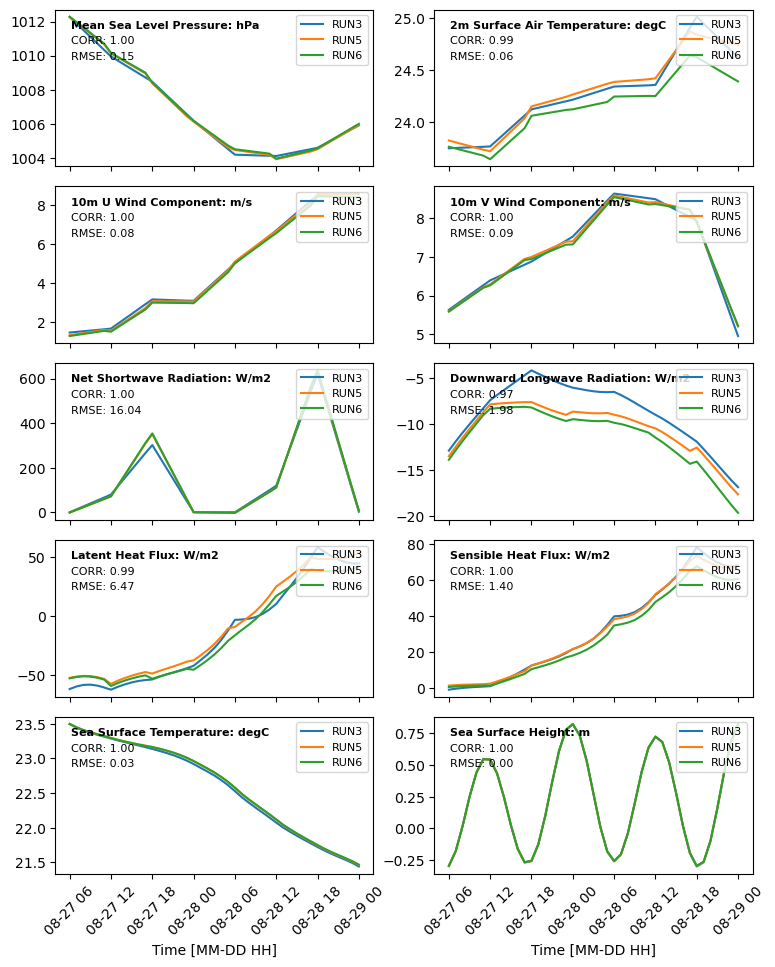

In [158]:
nrow = 5
ncol = 2
fig, ax = plt.subplots(nrow, ncol, figsize=(8,10))
x = pd.date_range("2011-08-27T06:00:00", "2011-08-29T00:00:00", freq="1h")

var_list = {
    'Pair'    : ['hPa' , 'MSLP'   , 'Mean Sea Level Pressure'], 
    'Tair'    : ['degC', 'T 2m'   , '2m Surface Air Temperature'], 
    'Uwind'   : ['m/s' , 'U 10m'  , '10m U Wind Component'], 
    'Vwind'   : ['m/s' , 'V 10m'  , '10m V Wind Component'], 
    'swrad'   : ['W/m2', 'SW net' , 'Net Shortwave Radiation'],
    'lwrad'   : ['W/m2', 'LW down', 'Downward Longwave Radiation'],
    'latent'  : ['W/m2', 'LH'     , 'Latent Heat Flux'],
    'sensible': ['W/m2', 'SH'     , 'Sensible Heat Flux'],
    'temp'    : ['degC', 'SST'    , 'Sea Surface Temperature'],
    'zeta'    : ['m'   , 'SSH'    , 'Sea Surface Height']
}

i = 0
for v in var_list.keys():
    irow = i // ncol
    icol = i % ncol

    data3 = ds[f"{v}"].isel(run_id=2).mean(dim=['eta_rho', 'xi_rho'])
    ax[irow,icol].plot(x, data3, label=f"RUN3")
    
    data5 = ds[f"{v}"].isel(run_id=4).mean(dim=['eta_rho', 'xi_rho'])
    ax[irow,icol].plot(x, data5, label=f"RUN5")

    data6 = ds[f"{v}"].isel(run_id=5).mean(dim=['eta_rho', 'xi_rho'])
    ax[irow,icol].plot(x, data6, label=f"RUN6")

    corr = np.corrcoef(data3, data5)[0, 1]
    rmse = np.sqrt(np.mean((data3 - data5) ** 2))
    
    if irow == nrow-1:
        ax[irow,icol].set_xlabel('Time [MM-DD HH]')
    else:
        ax[irow,icol].set_xticklabels([])
        ax[irow,icol].set_xlabel('')
    ax[irow,icol].tick_params(axis='x', labelrotation=45)
    ax[irow,icol].legend(ncol=1, fontsize=8, loc='upper right')
    ax[irow, icol].text(0.05, 0.9, f'{var_list[f'{v}'][2]}: {var_list[f'{v}'][0]}', fontsize=8, fontweight='bold', horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
    ax[irow, icol].text(0.05, 0.8, f'CORR: {corr:.2f}', fontsize=8, horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
    ax[irow, icol].text(0.05, 0.7, f'RMSE: {rmse:.2f}', fontsize=8, horizontalalignment='left', verticalalignment='center', multialignment='center', transform=ax[irow, icol].transAxes)
    
    i=i+1

# Remove remaining empty subplots
for j in range(i, nrow * ncol):
    irow = j // ncol
    icol = j % ncol
    ax[irow, icol].remove()

# Save figure
plt.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(f"Fig_run_3vs5.png")

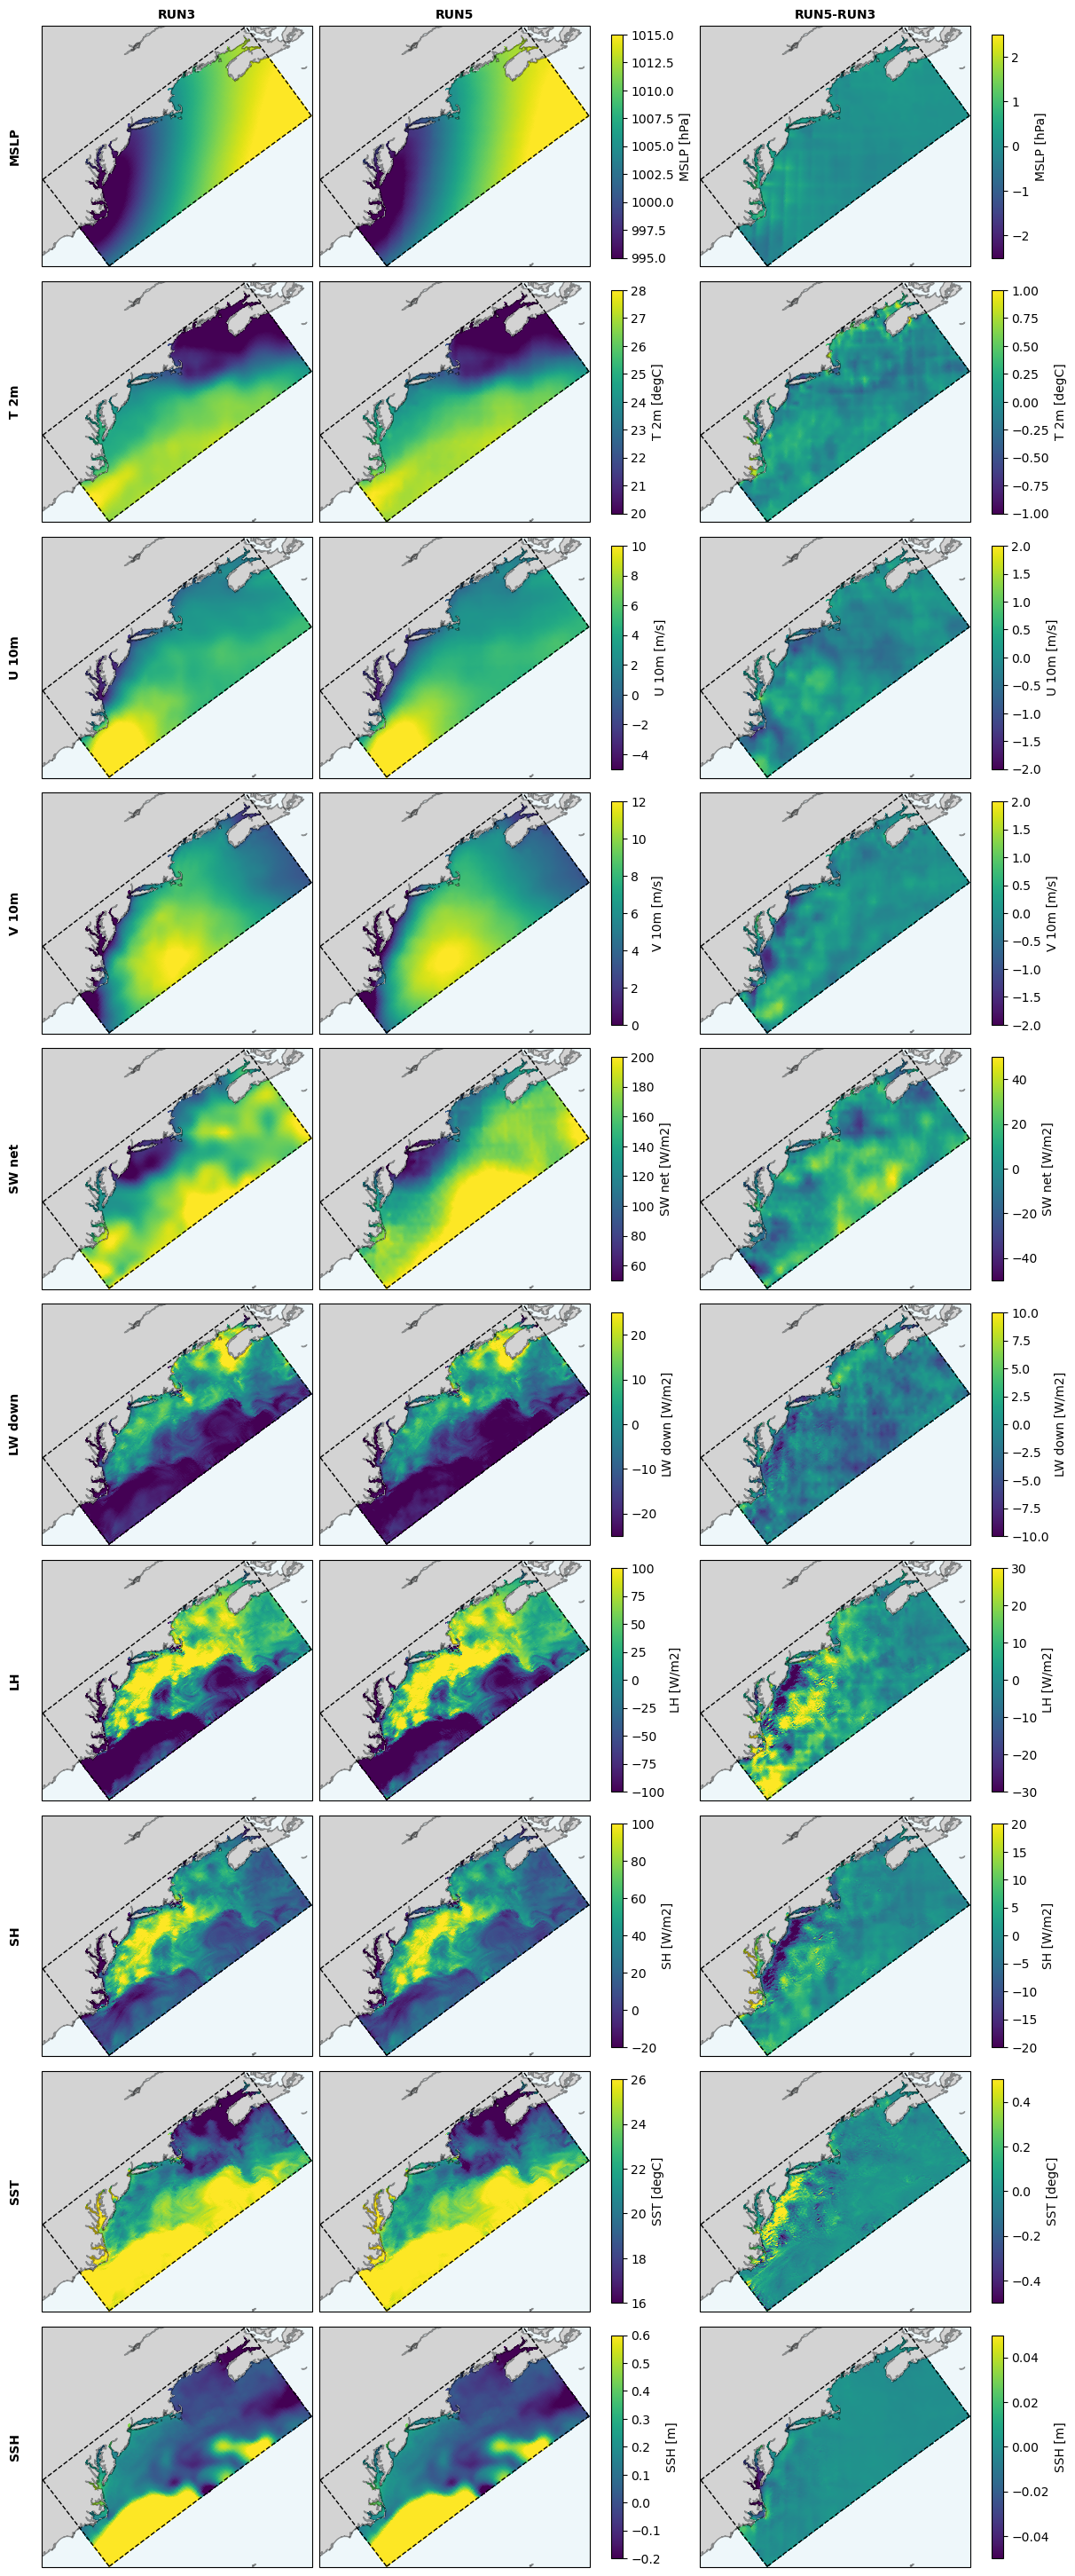

In [159]:
# Define bounding box limits
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

diff_range = {
    'Pair': [-2.5, 2.5],
    'Tair': [-1, 1],
    'Uwind': [-2, 2],
    'Vwind': [-2, 2],
    'swrad': [-50, 50],
    'lwrad': [-10, 10],
    'latent': [-30, 30],
    'sensible': [-20, 20],
    'temp': [-0.5, 0.5],
    'zeta' : [-0.05, 0.05]
}

# Create figure
nrow = 10
ncol = 3
fig, ax = plt.subplots(
    nrow, 
    ncol, 
    figsize=(12, 29), 
    layout='constrained', 
    subplot_kw={'projection': projection})

# Add plot
time_str = "2011-08-27T12:00:00"

i = 0
for v in var_list.keys():
    irow = i
    vmin, vmax = vars[f"{v}"]

    #data3 = ds[f"{v}"].isel(run_id=2).sel(ocean_time=t)
    data3 =  ds[f"{v}"].isel(run_id=2).mean(dim=['ocean_time'])
    im1 = ax[irow,0].pcolormesh(ds.lon_rho, ds.lat_rho, data3, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())

    #data5 = ds[f"{v}"].isel(run_id=4).sel(ocean_time=t)
    data5 =  ds[f"{v}"].isel(run_id=4).mean(dim=['ocean_time'])
    im2 = ax[irow,1].pcolormesh(ds.lon_rho, ds.lat_rho, data5, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    fig.colorbar(im2, ax=ax[irow,1], pad=0.08, aspect=20, shrink=0.9, label=f'{var_list[f'{v}'][1]} [{var_list[f'{v}'][0]}]')

    diff = data5-data3
    vmin, vmax = diff_range[f"{v}"]
    im3 = ax[irow,2].pcolormesh(ds.lon_rho, ds.lat_rho, diff, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    fig.colorbar(im3, ax=ax[irow,2], pad=0.08, aspect=20, shrink=0.9, label=f'{var_list[f'{v}'][1]} [{var_list[f'{v}'][0]}]')

    if irow == 0:
        ax[irow,0].set_title('RUN3', fontweight='bold', fontsize=10)
        ax[irow,1].set_title('RUN5', fontweight='bold', fontsize=10)
        ax[irow,2].set_title('RUN5-RUN3', fontweight='bold', fontsize=10)
    else:
        for icol in range(0, 3):
            ax[irow,icol].set_title("")

    ax[irow,0].text(-0.1, 0.5, f"{var_list[f'{v}'][1]}", transform=ax[irow,0].transAxes, rotation=90, ha='center', va='center', fontweight='bold', fontsize=10)

    # Add map features
    for icol in range(0, 3):
        ax[irow,icol].add_feature(cfeature.COASTLINE, alpha=0.4)
        ax[irow,icol].add_feature(cfeature.LAND, facecolor='lightgray')
        ax[irow,icol].add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

    # Add ROMS grid box
    for icol in range(0, 3):
        ax[irow,icol].plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
        ax[irow,icol].plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Left
        ax[irow,icol].plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Top
        ax[irow,icol].plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Right

    i = i+1

### Apply the Pearson correlation test to compare with MURR SST

In [160]:
from scipy.stats import pearsonr
# Function for spatial correlation and Pearson test
def calc_pearson(data1, data2, coords=["lat_rho", "lon_rho"]):
    # Dimensions
    lats = data2[coords[0]]
    lons = data2[coords[1]]

    # Initialize arrays to store results
    corr_coeff = np.empty(lats.shape)
    p_values = np.empty(lats.shape)

    # Flatten the grid for easier iteration
    num_points = lats.size
    lat_flat = lats.values.flatten()
    lon_flat = lons.values.flatten()

    # Process each grid point
    for idx in range(num_points):
        i, j = np.unravel_index(idx, lats.shape)

        # Extract time series at this grid point
        ts1 = data1[:, i, j].values
        ts2 = data2[:, i, j].values

        # Handle NaN values
        mask = ~np.isnan(ts1) & ~np.isnan(ts2)
        if np.any(mask):
            corr_coeff[i, j], p_values[i, j] = pearsonr(ts1[mask], ts2[mask])
        else:
            corr_coeff[i, j], p_values[i, j] = np.nan, np.nan

    # Save results as xarray Dataset
    result_ds = xr.Dataset({
        "corr_coeff": (["y", "x"], corr_coeff),
        "p_value": (["y", "x"], p_values),
    }, coords={"lat": (["y", "x"], lats.values), "lon": (["y", "x"], lons.values)})

    return result_ds

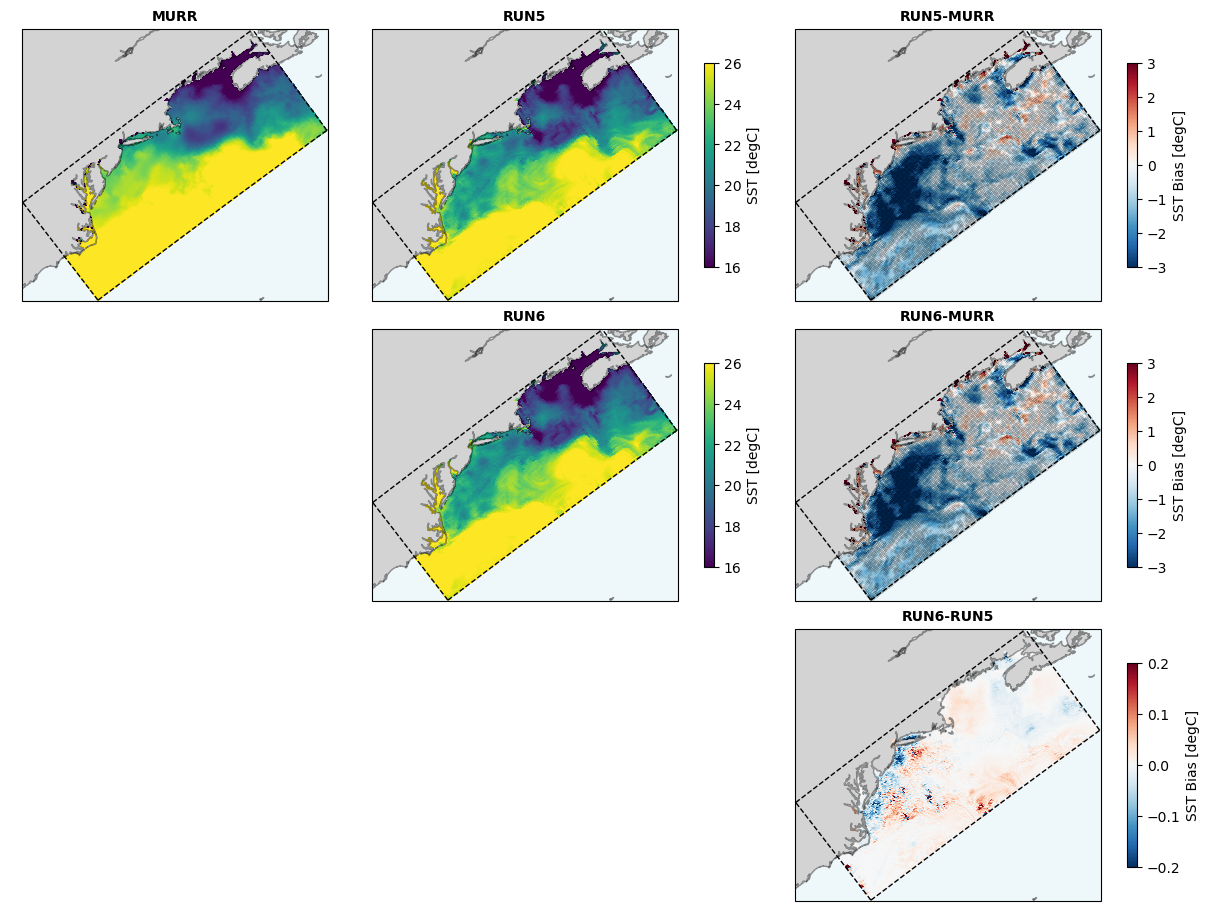

In [170]:
# Load datasets
ds_obs = xr.open_dataset("sst_murr_2011-08-21_2011-08-30_remap.nc").interp(time=x, method='linear')
data1 = ds_obs.analysed_sst-273.15
data2 = ds['temp'].isel(run_id=4)
data3 = ds['temp'].isel(run_id=5)

# Calculate corelations
data2_p = calc_pearson(data1, data2)
data3_p = calc_pearson(data1, data3)

# Load roms grid
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')

# Dimensions
lats = ds["lat_rho"]
lons = ds["lon_rho"]

# Define bounding box limits
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Plot data
fig, ax = plt.subplots(3, 3,
    figsize=(12, 9), 
    layout='constrained', 
    subplot_kw={'projection': projection})

vmin, vmax = vars["temp"]

# MURR vs. RUN5
data1_mean = data1.mean(dim=['time'])
im1 = ax[0,0].pcolormesh(lons, lats, data1_mean, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
ax[0,0].set_title('MURR', fontweight='bold', fontsize=10)
data2_mean = data2.mean(dim=['ocean_time'])
im2 = ax[0,1].pcolormesh(lons, lats, data2_mean, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
ax[0,1].set_title('RUN5', fontweight='bold', fontsize=10)
fig.colorbar(im2, ax=ax[0,1], pad=0.08, aspect=20, shrink=0.75, label='SST [degC]')
diff = data2_mean-data1_mean
im3 = ax[0,2].pcolormesh(lons, lats, diff, cmap='RdBu_r', vmin=-3, vmax=3, transform=ccrs.PlateCarree())
ax[0,2].set_title('RUN5-MURR', fontweight='bold', fontsize=10)
fig.colorbar(im3, ax=ax[0,2], pad=0.08, aspect=20, shrink=0.75, label='SST Bias [degC]')

# Regions with significant correlation
cond = data2_p.p_value < 0.01
cond_where = np.where(cond)
lats_where = lats.values[cond_where]
lons_where = lons.values[cond_where]
im3_add = ax[0,2].scatter(lons_where, lats_where, marker = '.', s = 0.05, c = 'k', alpha = 0.6, transform = ccrs.PlateCarree())

for icol in range(0, 3):
    # Add map features
    ax[0,icol].add_feature(cfeature.COASTLINE, alpha=0.4)
    ax[0,icol].add_feature(cfeature.LAND, facecolor='lightgray')
    ax[0,icol].add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

    # Add ROMS grid box
    ax[0,icol].plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
    ax[0,icol].plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Left
    ax[0,icol].plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Top
    ax[0,icol].plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Right

# MURR vs. RUN6
ax[1,0].axis('off')
data3_mean = data3.mean(dim=['ocean_time'])
im5 = ax[1,1].pcolormesh(lons, lats, data3_mean, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
ax[1,1].set_title('RUN6', fontweight='bold', fontsize=10)
fig.colorbar(im5, ax=ax[1,1], pad=0.08, aspect=20, shrink=0.75, label='SST [degC]')
diff = data3_mean-data1_mean
im6 = ax[1,2].pcolormesh(lons, lats, diff, cmap='RdBu_r', vmin=-3, vmax=3, transform=ccrs.PlateCarree())
ax[1,2].set_title('RUN6-MURR', fontweight='bold', fontsize=10)
fig.colorbar(im6, ax=ax[1,2], pad=0.08, aspect=20, shrink=0.75, label='SST Bias [degC]')

# Regions with significant correlation
cond = data3_p.p_value < 0.01
cond_where = np.where(cond)
lats_where = lats.values[cond_where]
lons_where = lons.values[cond_where]
im6_add = ax[1,2].scatter(lons_where, lats_where, marker = '.', s = 0.05, c = 'k', alpha = 0.6, transform = ccrs.PlateCarree())

for icol in range(1, 3):
    # Add map features
    ax[1,icol].add_feature(cfeature.COASTLINE, alpha=0.4)
    ax[1,icol].add_feature(cfeature.LAND, facecolor='lightgray')
    ax[1,icol].add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

    # Add ROMS grid box
    ax[1,icol].plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
    ax[1,icol].plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Left
    ax[1,icol].plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Top
    ax[1,icol].plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Right

# RUN5 vs. RUN6
ax[2,0].axis('off')
ax[2,1].axis('off')
diff = data3_mean-data2_mean
im7 = ax[2,2].pcolormesh(lons, lats, diff, cmap='RdBu_r', vmin=-0.2, vmax=0.2, transform=ccrs.PlateCarree())
ax[2,2].set_title('RUN6-RUN5', fontweight='bold', fontsize=10)
fig.colorbar(im7, ax=ax[2,2], pad=0.08, aspect=20, shrink=0.75, label='SST Bias [degC]')

for icol in range(2, 3):
    # Add map features
    ax[2,icol].add_feature(cfeature.COASTLINE, alpha=0.4)
    ax[2,icol].add_feature(cfeature.LAND, facecolor='lightgray')
    ax[2,icol].add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

    # Add ROMS grid box
    ax[2,icol].plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
    ax[2,icol].plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Left
    ax[2,icol].plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Top
    ax[2,icol].plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Right

### Spatial plots for input forcing for each run

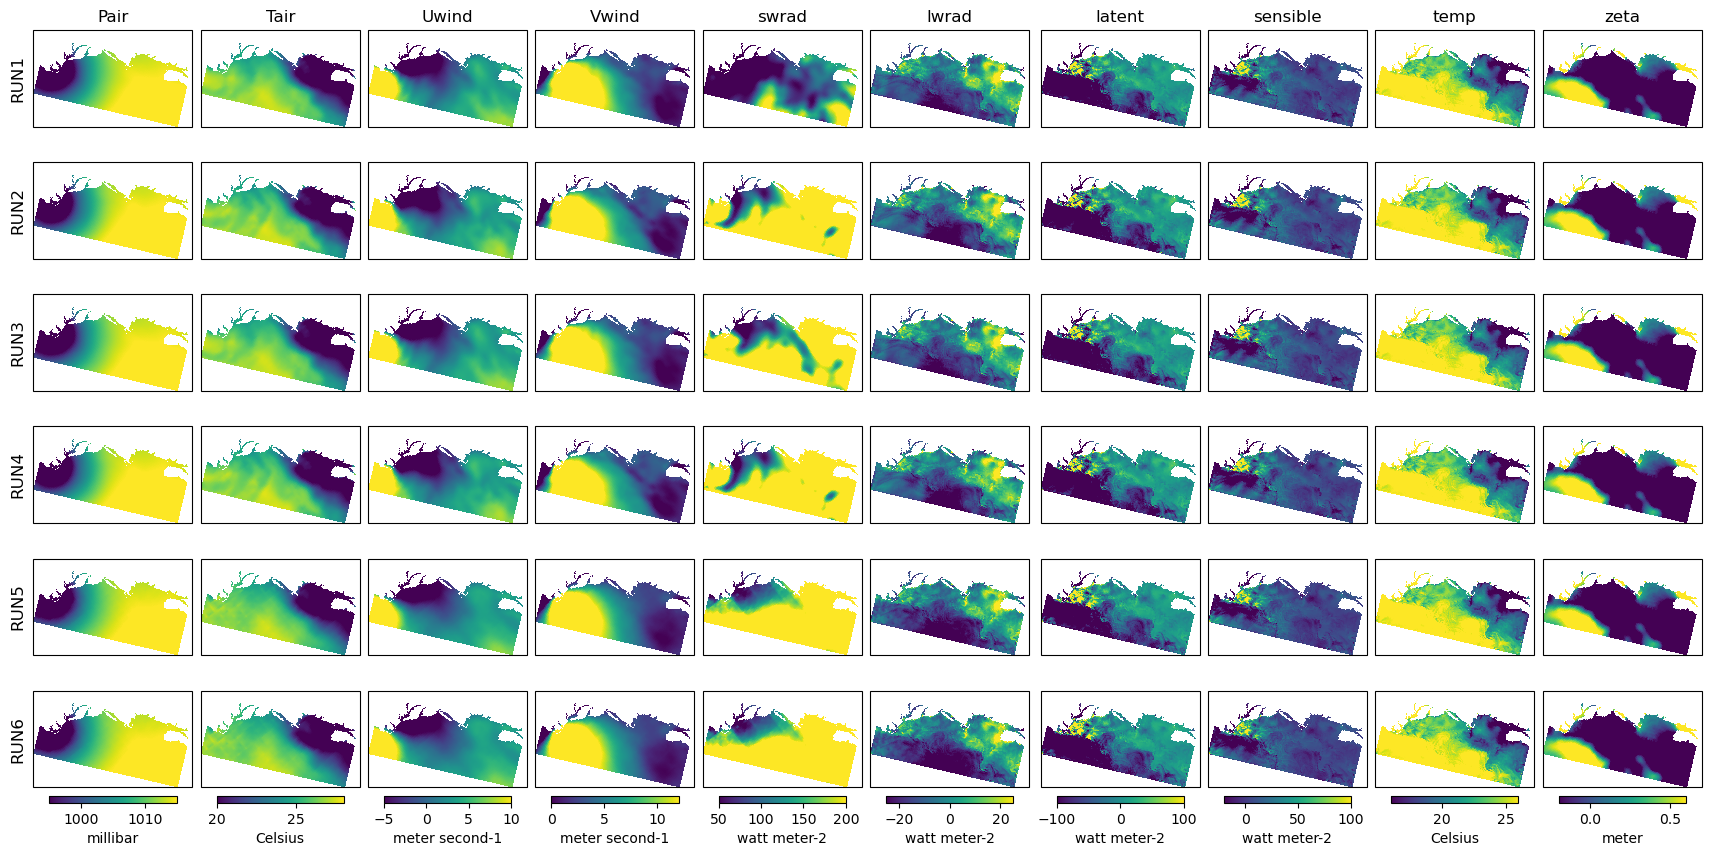

In [172]:
# Define bounding box limits
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Create figure
nrow = ds.run_id.shape[0] # number of datasets
ncol = len(var_names) # number of variables
fig, ax = plt.subplots(
    nrow, 
    ncol, 
    figsize=(17, 8.5), 
    layout='constrained', 
    subplot_kw={'projection': projection})

# Set timestep
tindx = 10

# Add figure title
#fig.suptitle(f"Time: {ds[var_name].isel(ocean_time=tindx).ocean_time.values}", fontsize=12)

# Add sub plots
im = []
for icol in range(ncol):
    for irow in range(nrow):
        var_name = var_names[icol]
        vmin, vmax = vars[var_name]
        im.append(ds[var_name].isel(run_id=irow, ocean_time=10).plot(ax=ax[irow,icol], transform=ccrs.LambertConformal(), vmin=vmin, vmax=vmax, cmap='viridis', add_colorbar=False))
        if irow == 0:
            ax[irow,icol].set_title(var_name)
        else:
            ax[irow,icol].set_title("")
        if icol == 0:
            ax[irow,icol].text(-0.1, 0.5, f"RUN{irow+1}", transform=ax[irow,icol].transAxes, rotation=90, ha='center', va='center', fontsize=12)
        ax[irow,icol].coastlines()
    fig.colorbar(im[-1], ax=ax[:,icol], location='bottom', pad=0.01, aspect=20, shrink=0.8, label=ds[var_name].units)